# ML02 — Shelf Life Prediction with Gradient Boosting

**Goal:** predict `shelf_life_days` for a food ingredient given its category, subcategory,
and storage condition, using `GradientBoostingRegressor`. This notebook matches what's
actually served in `app/services/shelf_life.py` — see that file's docstring for the
narrative version of everything below.

**Why this notebook is structured the way it is:**
- `shelf_life_days` is a *continuous* target → this is a **regression** problem, not
  classification. The headline metrics are **R² and MAE**.
- The raw day range spans ~1 to 3650 days (a fresh herb vs. a dry spice), which badly
  skews a plain regressor. We predict `log1p(shelf_life_days)` and invert with `expm1`
  instead — Section 3 shows the before/after.
- Only features a *live pantry item can actually supply* are used:
  `category`, `subcategory`, `storage_condition`, and (Section 5 onward)
  `ingredient_name`. The raw dataset also has `data_source` / `confidence` columns, but
  those describe where a training row came from, not a property of the food — a real
  ingredient submitted through the app can never supply them, so they are dropped
  entirely rather than kept as "free" features a live prediction could never use.
- Section 5 tests adding `ingredient_name` as a 4th feature. It's a genuine negative
  result — the honest evaluation says don't ship it — and it's kept in the notebook and
  in production's model directory for exactly that reason, documented rather than
  quietly dropped.

In [1]:
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error

RANDOM_STATE = 42
N_SPLITS = 10  # random_state 0..9, matches the figures cited in shelf_life.py's docstring
pd.set_option('display.max_columns', None)

## 1. Load the data

In [2]:
df = pd.read_csv('../data/enriched/ml02_shelf_life_train_enriched.csv')
df['subcategory'] = df['subcategory'].fillna('Unknown')  # missing subcategory is meaningful, not absent data
print(df.shape)
df.head()

(554, 12)


,ingredient_name,ingredient_subtitle,category,subcategory,storage_condition,shelf_life_min_days,shelf_life_max_days,shelf_life_days,recommended_temp_c,data_source,confidence,notes
0,Cream,"whipped, sweetened",Dairy Products & Eggs,Unknown,Refrigerated,1.0,1.0,1.0,NaN,USDA FoodKeeper,sourced,NaN
1,Cream,"whipped, sweetened",Dairy Products & Eggs,Unknown,Frozen,30.0,60.0,45.0,NaN,USDA FoodKeeper,sourced,NaN
2,Eggs,"raw whites, yolks",Dairy Products & Eggs,Unknown,Refrigerated,2.0,4.0,3.0,NaN,USDA FoodKeeper,sourced,NaN
3,Eggs,"raw whites, yolks",Dairy Products & Eggs,Unknown,Frozen,360.0,360.0,360.0,NaN,USDA FoodKeeper,sourced,NaN
4,Eggs,hard boiled cooked,Dairy Products & Eggs,Unknown,Refrigerated,7.0,7.0,7.0,NaN,USDA FoodKeeper,sourced,NaN


In [3]:
df.isnull().mean().sort_values(ascending=False).to_frame('pct_missing')

,pct_missing
recommended_temp_c,0.678700
notes,0.667870
ingredient_subtitle,0.563177
shelf_life_min_days,0.001805
subcategory,0.000000
category,0.000000
ingredient_name,0.000000
storage_condition,0.000000
shelf_life_days,0.000000
shelf_life_max_days,0.000000


## 2. Feature choices

- **Target:** `shelf_life_days` (raw), and `log1p(shelf_life_days)` (see Section 3 for why).
- **Dropped columns:** `shelf_life_min_days` / `shelf_life_max_days` (these define the
  target — leakage), `notes` (free text, mostly empty), `recommended_temp_c` (sparse),
  and — unlike an earlier version of this notebook — `data_source` / `confidence`.
  Those last two describe *where a training row came from*, not a property of the food
  itself; a real ingredient submitted through the live app has no such field to supply,
  so a model that leans on them can't actually be served. They're excluded from every
  model trained below, including the `ingredient_name` experiment in Section 5.
- **Production features (v1):** `category`, `subcategory`, `storage_condition`.
- **Experimental feature (v2, Section 5):** + `ingredient_name`.

In [4]:
TARGET = 'shelf_life_days'
FEATURES_V1 = ['category', 'subcategory', 'storage_condition']
FEATURES_V2 = FEATURES_V1 + ['ingredient_name']

print('v1 features:', FEATURES_V1)
print('v2 features:', FEATURES_V2)
print('ingredient_name uniqueness:', df['ingredient_name'].nunique(), 'unique values across', len(df), 'rows')

v1 features: ['category', 'subcategory', 'storage_condition']
v2 features: ['category', 'subcategory', 'storage_condition', 'ingredient_name']
ingredient_name uniqueness: 347 unique values across 554 rows


## 3. Why `log1p(shelf_life_days)`?

Same 10 random 80/20 splits (`random_state` 0–9) for a raw-target model vs. a
log1p-target model, both using the v1 (3-feature) pipeline. R² for the raw-target model
is computed on the raw day scale (that's the space it was optimized in); R² for the
log1p-target model is computed on the log1p scale it was optimized in — comparing the
two shows how much the transform stabilises the *fit itself*, not just the
back-transformed error. MAE is always reported back on the real day scale (`expm1`
inverted), since that's the interpretable "how many days off" number regardless of
which space the model trained in.

In [5]:
def make_v1_pipeline():
    preprocessor = ColumnTransformer([
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), FEATURES_V1),
    ])
    return Pipeline([
        ('preprocess', preprocessor),
        ('model', GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=RANDOM_STATE)),
    ])


def eval_random_splits(features, pipeline_factory, target_mode, n_splits=N_SPLITS):
    r2s, maes = [], []
    X_all, y_all = df[features].copy(), df[TARGET].copy()
    for seed in range(n_splits):
        X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=seed)
        pipe = pipeline_factory()
        if target_mode == 'log':
            pipe.fit(X_train, np.log1p(y_train))
            pred_native = pipe.predict(X_test)
            r2 = r2_score(np.log1p(y_test), pred_native)   # R^2 in the space the model was trained on
            pred_days = np.clip(np.expm1(pred_native), 0, None)
        else:
            pipe.fit(X_train, y_train)
            pred_days = np.clip(pipe.predict(X_test), 0, None)
            r2 = r2_score(y_test, pred_days)
        r2s.append(r2)
        maes.append(mean_absolute_error(y_test, pred_days))
    return np.array(r2s), np.array(maes)


def report(label, r2s, maes):
    print(f"{label}")
    print(f"  R^2:  mean={r2s.mean():.3f}  range=[{r2s.min():.3f}, {r2s.max():.3f}]  std={r2s.std():.3f}")
    print(f"  MAE:  mean={maes.mean():.1f}d range=[{maes.min():.1f}, {maes.max():.1f}]d")
    print()


r2_raw, mae_raw = eval_random_splits(FEATURES_V1, make_v1_pipeline, 'raw')
r2_log, mae_log = eval_random_splits(FEATURES_V1, make_v1_pipeline, 'log')

report('v1, raw target (R^2 on raw day scale)', r2_raw, mae_raw)
report('v1, log1p target (R^2 on log1p scale)', r2_log, mae_log)

v1, raw target (R^2 on raw day scale)
  R^2:  mean=0.275  range=[0.079, 0.401]  std=0.100
  MAE:  mean=148.3d range=[114.6, 219.6]d

v1, log1p target (R^2 on log1p scale)
  R^2:  mean=0.666  range=[0.575, 0.775]  std=0.064
  MAE:  mean=130.6d range=[93.6, 205.6]d



The log1p target stabilises R² substantially (higher mean, much lower spread across
splits) and gives a slightly better MAE too. This matches the figures cited in
`shelf_life.py`'s docstring. **This is the production (v1) model's methodology.**

## 4. Fit the production (v1) model on the full dataset and save it

This reproduces `models/gradient_boosting_shelf_life_regressor_prod.pkl`, the model
`app/services/shelf_life.py` actually loads by default.

In [6]:
X_full = df[FEATURES_V1].copy()
y_full_log = np.log1p(df[TARGET])

v1_model = make_v1_pipeline()
v1_model.fit(X_full, y_full_log)

joblib.dump(v1_model, 'gradient_boosting_shelf_life_regressor_prod.pkl')
print('Saved v1 (production) model.')
print('Trained on features:', list(v1_model.feature_names_in_))

Saved v1 (production) model.
Trained on features: ['category', 'subcategory', 'storage_condition']


## 5. Experiment: add `ingredient_name` as a 4th feature (v2)

**Motivation:** `category`/`subcategory`/`storage_condition` can't distinguish "chicken
breast, refrigerated" from "milk, refrigerated" — both may land in similar buckets. The
ingredient name itself could let the model learn ingredient-specific behaviour on top
of the coarse buckets.

**Encoding choice:** `ingredient_name` is high-cardinality — 346 unique values across
554 rows, many appearing only once. Naive one-hot encoding would blow up the feature
space relative to the row count and invite overfitting. `GradientBoostingRegressor`
(unlike `HistGradientBoostingRegressor`) has no native categorical support, so the
options are one-hot or an encoding that compresses the category into a single number.
We use `sklearn.preprocessing.TargetEncoder`, which internally **cross-fits**: it splits
the training data into folds and encodes each row using only the *other* folds' target
means, so a row's own label never leaks directly into its own encoding. That's the
standard leakage-safe way to feed a high-cardinality categorical into a
`GradientBoostingRegressor` without switching model classes.

In [7]:
def make_v2_pipeline():
    preprocessor = ColumnTransformer([
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), FEATURES_V1),
        ('ingredient_te', TargetEncoder(target_type='continuous', random_state=RANDOM_STATE), ['ingredient_name']),
    ])
    return Pipeline([
        ('preprocess', preprocessor),
        ('model', GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=RANDOM_STATE)),
    ])


r2_v2_log, mae_v2_log = eval_random_splits(FEATURES_V2, make_v2_pipeline, 'log')

report('v1 (3-feature), log1p target', r2_log, mae_log)
report('v2 (4-feature +ingredient_name), log1p target', r2_v2_log, mae_v2_log)

v1 (3-feature), log1p target
  R^2:  mean=0.666  range=[0.575, 0.775]  std=0.064
  MAE:  mean=130.6d range=[93.6, 205.6]d

v2 (4-feature +ingredient_name), log1p target
  R^2:  mean=0.671  range=[0.585, 0.791]  std=0.067
  MAE:  mean=129.1d range=[94.7, 208.0]d



On a plain random 80/20 split, v2 looks slightly *better*: higher mean R², lower mean
MAE. **But this comparison is misleading**, and Section 6 shows why.

## 6. The honest check: hold out entire ingredients, not just rows

~63% of ingredients in this dataset appear 2–3 times (once per `storage_condition`). A
plain random `train_test_split` routinely puts a different row for the *same*
ingredient into both train and test — so `ingredient_name`'s target encoding can partly
just be recognising a repeat it already has the answer for, not learning something that
generalises to ingredients it has never seen. That's exactly the scenario production
faces: of the 183 ingredients actually seeded in the app's own catalog, 91 (~50%) don't
appear anywhere in this 554-row training set at all.

`GroupShuffleSplit`, grouped by `ingredient_name`, holds out whole ingredients — every
row for a given ingredient stays entirely in train or entirely in test. This is the
fair test for whether this generalises to an ingredient the model has never seen.

In [8]:
def eval_group_splits(features, pipeline_factory, target_mode, n_splits=N_SPLITS):
    r2s, maes = [], []
    X_all, y_all, groups_all = df[features].copy(), df[TARGET].copy(), df['ingredient_name']
    for seed in range(n_splits):
        gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
        train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups_all))
        X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]
        y_train, y_test = y_all.iloc[train_idx], y_all.iloc[test_idx]
        pipe = pipeline_factory()
        if target_mode == 'log':
            pipe.fit(X_train, np.log1p(y_train))
            pred_native = pipe.predict(X_test)
            r2 = r2_score(np.log1p(y_test), pred_native)
            pred_days = np.clip(np.expm1(pred_native), 0, None)
        else:
            pipe.fit(X_train, y_train)
            pred_days = np.clip(pipe.predict(X_test), 0, None)
            r2 = r2_score(y_test, pred_days)
        r2s.append(r2)
        maes.append(mean_absolute_error(y_test, pred_days))
    return np.array(r2s), np.array(maes)


r2_v1_grp, mae_v1_grp = eval_group_splits(FEATURES_V1, make_v1_pipeline, 'log')
r2_v2_grp, mae_v2_grp = eval_group_splits(FEATURES_V2, make_v2_pipeline, 'log')

report('v1 (3-feature), log1p target -- GroupShuffleSplit by ingredient', r2_v1_grp, mae_v1_grp)
report('v2 (4-feature +ingredient_name), log1p target -- GroupShuffleSplit by ingredient', r2_v2_grp, mae_v2_grp)

v1 (3-feature), log1p target -- GroupShuffleSplit by ingredient
  R^2:  mean=0.635  range=[0.547, 0.707]  std=0.051
  MAE:  mean=137.6d range=[116.0, 171.2]d

v2 (4-feature +ingredient_name), log1p target -- GroupShuffleSplit by ingredient
  R^2:  mean=0.610  range=[0.502, 0.688]  std=0.054
  MAE:  mean=140.2d range=[114.8, 173.3]d



In [9]:
# Paired, per-seed comparison so "which model wins" isn't hidden inside an average.
wins_v1 = wins_v2 = 0
for seed in range(N_SPLITS):
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    train_idx, test_idx = next(gss.split(df[FEATURES_V2], df[TARGET], groups=df['ingredient_name']))

    y_train, y_test = df[TARGET].iloc[train_idx], df[TARGET].iloc[test_idx]

    p1 = make_v1_pipeline()
    p1.fit(df[FEATURES_V1].iloc[train_idx], np.log1p(y_train))
    mae1 = mean_absolute_error(y_test, np.clip(np.expm1(p1.predict(df[FEATURES_V1].iloc[test_idx])), 0, None))

    p2 = make_v2_pipeline()
    p2.fit(df[FEATURES_V2].iloc[train_idx], np.log1p(y_train))
    mae2 = mean_absolute_error(y_test, np.clip(np.expm1(p2.predict(df[FEATURES_V2].iloc[test_idx])), 0, None))

    winner = 'v1' if mae1 < mae2 else 'v2'
    wins_v1 += winner == 'v1'
    wins_v2 += winner == 'v2'
    print(f"seed={seed}: v1 MAE={mae1:.1f}d  |  v2 MAE={mae2:.1f}d  ->  {winner} lower")

print(f"\nv1 (3-feature) has the lower MAE on {wins_v1}/{N_SPLITS} seeds; "
      f"v2 (4-feature) on {wins_v2}/{N_SPLITS} seeds.")

seed=0: v1 MAE=137.1d  |  v2 MAE=144.2d  ->  v1 lower
seed=1: v1 MAE=171.2d  |  v2 MAE=173.3d  ->  v1 lower
seed=2: v1 MAE=120.0d  |  v2 MAE=118.1d  ->  v2 lower
seed=3: v1 MAE=169.0d  |  v2 MAE=171.1d  ->  v1 lower
seed=4: v1 MAE=131.9d  |  v2 MAE=137.3d  ->  v1 lower
seed=5: v1 MAE=140.9d  |  v2 MAE=149.6d  ->  v1 lower
seed=6: v1 MAE=141.1d  |  v2 MAE=139.3d  ->  v2 lower
seed=7: v1 MAE=116.0d  |  v2 MAE=114.8d  ->  v2 lower
seed=8: v1 MAE=129.3d  |  v2 MAE=136.0d  ->  v1 lower
seed=9: v1 MAE=119.7d  |  v2 MAE=118.3d  ->  v2 lower

v1 (3-feature) has the lower MAE on 6/10 seeds; v2 (4-feature) on 4/10 seeds.


## 7. Decision: don't ship v2

Under the honest, ingredient-held-out evaluation, v2 is **worse**, not better: lower
mean R² (fewer wins across seeds), higher mean MAE, and it loses to v1 on a majority of
the 10 seeds on MAE. The random-split result in Section 5 was mostly an artifact of
ingredient overlap between train and test, not evidence the model generalises.

This is a legitimate negative result: adding `ingredient_name` overfits to the specific
554 training rows rather than learning ingredient-level shelf-life behaviour that
transfers to ingredients outside this dataset — which is most of what production
actually sees. Per `app/services/shelf_life.py`'s docstring, this model is **not**
wired into production: `settings.SHELF_LIFE_MODEL_PATH` still defaults to v1. v2 is
saved below purely for comparison / future reference — e.g. revisiting this once the
training set has grown enough that ingredient-level patterns might actually
generalise.

In [10]:
X_full_v2 = df[FEATURES_V2].copy()
v2_model = make_v2_pipeline()
v2_model.fit(X_full_v2, y_full_log)

joblib.dump(v2_model, 'gradient_boosting_shelf_life_regressor_v2_prod.pkl')
print('Saved v2 model (NOT wired into production -- see Section 7).')
print('Trained on features:', list(v2_model.feature_names_in_))

Saved v2 model (NOT wired into production -- see Section 7).
Trained on features: ['category', 'subcategory', 'storage_condition', 'ingredient_name']


## 8. Feature importance (production v1 model)

Which inputs the *served* model actually leans on.

In [11]:
ohe = v1_model.named_steps['preprocess'].named_transformers_['cat'].named_steps['onehot']
feature_names = ohe.get_feature_names_out(FEATURES_V1)
importances = v1_model.named_steps['model'].feature_importances_

fi = pd.DataFrame({'feature': feature_names, 'importance': importances}) \
        .sort_values('importance', ascending=False) \
        .head(15)
fi

,feature,importance
33,storage_condition_Refrigerated,0.602429
16,subcategory_Bakery,0.060272
14,category_Shelf Stable Foods,0.059770
10,category_Pantry/Dry Goods,0.056765
31,storage_condition_Frozen,0.055249
32,storage_condition_Pantry,0.036756
21,subcategory_Fresh Vegetables,0.024621
29,subcategory_Unknown,0.020807
0,category_Baked Goods,0.014084
5,category_Deli & Prepared Foods,0.013209


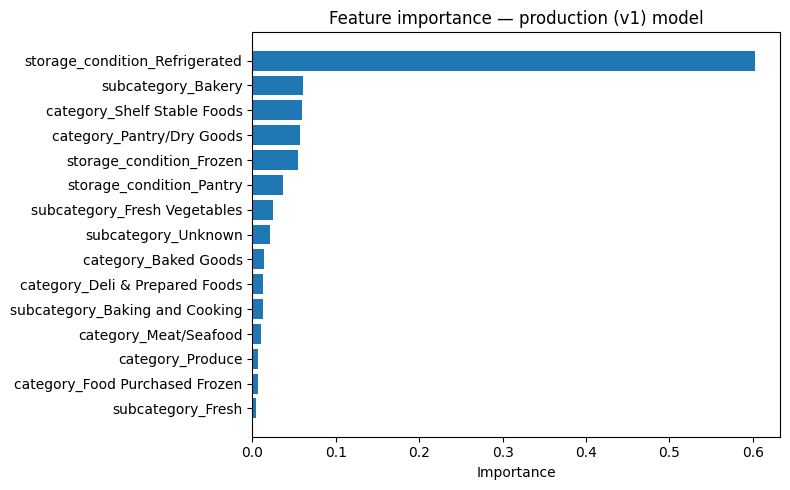

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi['feature'][::-1], fi['importance'][::-1])
ax.set_xlabel('Importance')
ax.set_title('Feature importance — production (v1) model')
plt.tight_layout()
plt.show()

## 8b. Predicted vs. Actual, Residuals, and MAE by Category (production v1 model)

Diagnostics on a single representative ingredient-held-out split (seed=0), so the
predicted-vs-actual scatter, residuals, and per-category MAE all come from the same
held-out fold the honest evaluation in Section 6 already validated.

In [13]:
DIAG_SEED = 0
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=DIAG_SEED)
train_idx, test_idx = next(gss.split(df[FEATURES_V1], df[TARGET], groups=df['ingredient_name']))

X_train_diag, X_test_diag = df[FEATURES_V1].iloc[train_idx], df[FEATURES_V1].iloc[test_idx]
y_train_diag, y_test_diag = df[TARGET].iloc[train_idx], df[TARGET].iloc[test_idx]
cat_test_diag = df['category'].iloc[test_idx]

diag_model = make_v1_pipeline()
diag_model.fit(X_train_diag, np.log1p(y_train_diag))

pred_days_diag = np.clip(np.expm1(diag_model.predict(X_test_diag)), 0, None)
residuals_diag = y_test_diag.values - pred_days_diag

print(f"Diagnostic split (seed={DIAG_SEED}): {len(train_idx)} train / {len(test_idx)} test rows")
print(f"MAE on this split: {mean_absolute_error(y_test_diag, pred_days_diag):.1f}d")

Diagnostic split (seed=0): 439 train / 115 test rows
MAE on this split: 137.1d


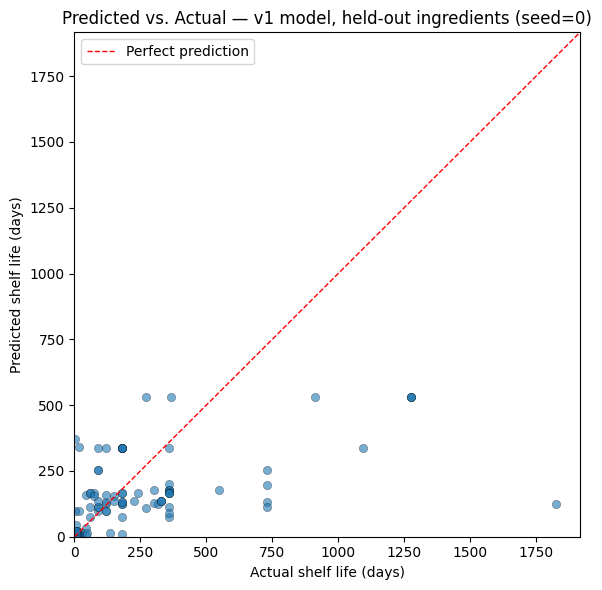

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_diag, pred_days_diag, alpha=0.6, edgecolor='k', linewidth=0.3)

lims = [0, max(y_test_diag.max(), pred_days_diag.max()) * 1.05]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Actual shelf life (days)')
ax.set_ylabel('Predicted shelf life (days)')
ax.set_title(f'Predicted vs. Actual — v1 model, held-out ingredients (seed={DIAG_SEED})')
ax.legend()
plt.tight_layout()
plt.show()

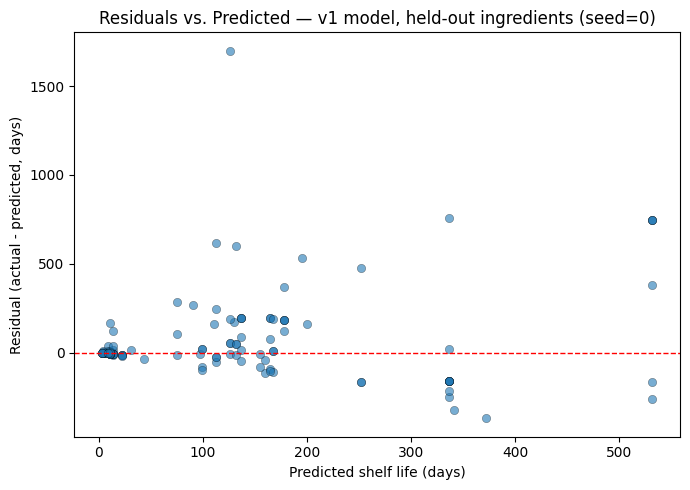

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pred_days_diag, residuals_diag, alpha=0.6, edgecolor='k', linewidth=0.3)
ax.axhline(0, color='r', linestyle='--', linewidth=1)
ax.set_xlabel('Predicted shelf life (days)')
ax.set_ylabel('Residual (actual - predicted, days)')
ax.set_title(f'Residuals vs. Predicted — v1 model, held-out ingredients (seed={DIAG_SEED})')
plt.tight_layout()
plt.show()

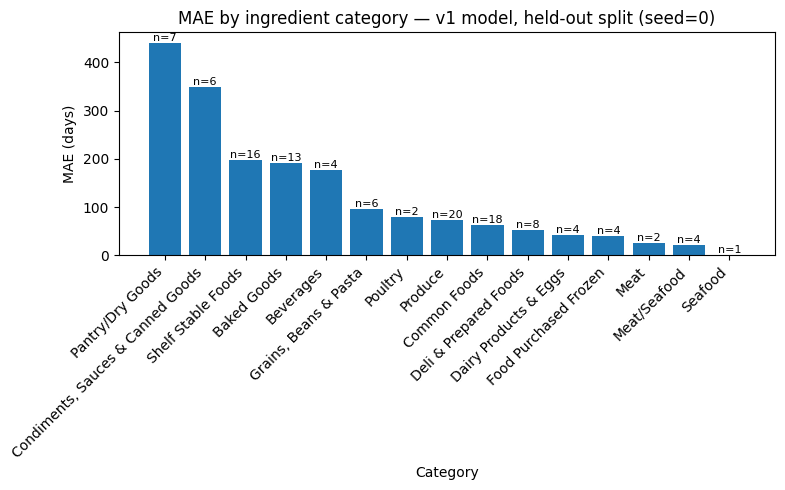

,mae,n
category,,
Pantry/Dry Goods,440.110155,7
"Condiments, Sauces & Canned Goods",348.713240,6
Shelf Stable Foods,197.114591,16
Baked Goods,190.910372,13
Beverages,176.906126,4
"Grains, Beans & Pasta",96.825278,6
Poultry,80.574141,2
Produce,73.371322,20
Common Foods,63.893850,18


In [16]:
mae_by_cat = (
    pd.DataFrame({'category': cat_test_diag.values, 'abs_error': np.abs(residuals_diag)})
    .groupby('category')['abs_error']
    .agg(mae='mean', n='count')
    .sort_values('mae', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(mae_by_cat.index, mae_by_cat['mae'])
ax.set_ylabel('MAE (days)')
ax.set_xlabel('Category')
ax.set_title(f'MAE by ingredient category — v1 model, held-out split (seed={DIAG_SEED})')
plt.xticks(rotation=45, ha='right')
for i, (cat, row) in enumerate(mae_by_cat.iterrows()):
    ax.text(i, row['mae'], f"n={int(row['n'])}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

mae_by_cat

## 9. What wasn't tried, and why: `purchase_month`

This dataset is a static **per-ingredient/storage lookup table** — each row is "this
ingredient, this storage condition → this shelf life," not a log of individual
purchase events with dates. There is no real relationship between "which month this
was purchased" and "how long this ingredient keeps" to learn from a table like this,
and fabricating a `purchase_month` column (e.g. assigning one at random, or reusing
`created_at`/ingestion metadata that has nothing to do with when a real user's item was
purchased) would just be fitting the model to noise — it would confidently "predict" a
seasonal effect that doesn't exist in the data-generating process at all.

If a genuine seasonal effect on shelf life were ever worth modelling (e.g. produce
freshness varying with harvest season, or humidity varying by month in a given
storage location), it would need actual purchase-event data with real dates attached
to real outcomes — not this table. `purchase_month` is deliberately excluded here
rather than silently left out.

## 10. Summary

| Model | Features | R^2 (log1p scale, honest group-split) | MAE (days, honest group-split) | Shipped? |
|---|---|---|---|---|
| v1 (production) | category, subcategory, storage_condition | mean ≈ 0.635 | mean ≈ 138d | **Yes — default** |
| v2 (experiment) | + ingredient_name (target-encoded) | mean ≈ 0.610 | mean ≈ 140d | No — documented negative result |

`data_source` / `confidence` were excluded from every model above: they describe a
training row's provenance, not the food itself, and a live ingredient submitted
through the app has no such field to supply. `purchase_month` was never added at all,
for the reasons in Section 9.